# Article 8: Scaling & Load Testing - Measured Results

This notebook charts the empirical behaviour of the RAG + Agent service under four locust load scenarios run against a Docker Desktop Kubernetes cluster (Apple M4 Pro, 16GB).

**Scenarios** (all routed through a NodePort sibling Service so kube-proxy load-balances across replicas):

| Scenario | Users | Replicas | Duration | Purpose |
|---|---|---|---|---|
| `rampup_r2` | ramp 0->100 | 2 | ~5 min | Stage 1 saturation curve |
| `sustained_r2` | 50 | 2 | 5 min | Steady-state baseline at r=2 |
| `spike_r2` | 200 | 2 | 2 min | Saturation cliff |
| `sustained_r5` | 50 | 5 | 5 min | Replica-scaling A/B at fixed load |

**HPA is disabled (D5)**: replica counts are pinned by `kubectl scale deployment` so each scenario isolates a single variable. HPA reaction time is documented as future work in the JSON.

The four charts that follow correspond to the four article-worthy findings:

1. **Throughput curve** - shows where rps stops growing with concurrent users.
2. **Event-loop contention** - `/health` p95 as a thermometer for FastAPI loop pressure.
3. **Replica comparison** - r=2 vs r=5 at fixed sustained load, below the cliff.
4. **Saturation cliff** - the spike scenario where the 2-replica setup breaks.

In [1]:
import csv
import json
import os
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np

CHART_DIR = Path("../results/charts/article_08")
DATA_DIR = Path("../results/data")
CHART_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

In [2]:
data = json.loads((DATA_DIR / "article_08_benchmarks.json").read_text())
assert data["mode"] == "measured", "Re-run benchmarks/run_article_08.py --mode measured before opening this notebook"

scenarios = data["scenarios"]
print("Scenarios loaded:", list(scenarios.keys()))
for name, s in scenarios.items():
    a = s["aggregate"]
    print(f"  {name:14s} req={a['requests']:5d} fail={a['failures']:4d} rps={a['rps']:6.2f} p50={a['p50_ms']/1000:6.2f}s p95={a['p95_ms']/1000:6.2f}s")

Scenarios loaded: ['rampup_r2', 'sustained_r2', 'spike_r2', 'sustained_r5']
  rampup_r2      req= 1357 fail=   0 rps=  4.54 p50= 14.00s p95= 60.00s
  sustained_r2   req= 1090 fail=   0 rps=  3.64 p50= 10.00s p95= 43.00s
  spike_r2       req= 4359 fail=3724 rps= 36.50 p50=  0.00s p95= 30.00s
  sustained_r5   req= 1174 fail=   0 rps=  3.93 p50= 10.00s p95= 38.00s


In [3]:
def load_history(prefix: str) -> list[dict[str, float]]:
    """Read locust per-second history CSV; return only Aggregated rows.

    The Aggregated row at each timestamp blends RAG, agent, and health endpoints;
    we use it as the cluster-wide throughput/latency signal.
    """
    rows: list[dict[str, float]] = []
    path = DATA_DIR / f"article_08_locust_{prefix}_stats_history.csv"
    with path.open() as f:
        reader = csv.DictReader(f)
        for r in reader:
            if r.get("Name") != "Aggregated":
                continue
            try:
                rows.append({
                    "t": float(r["Timestamp"]),
                    "users": float(r["User Count"]),
                    "rps": float(r["Requests/s"]) if r["Requests/s"] else 0.0,
                    "fps": float(r["Failures/s"]) if r["Failures/s"] else 0.0,
                    "p50": float(r["50%"]) if r["50%"] else 0.0,
                    "p95": float(r["95%"]) if r["95%"] else 0.0,
                    "p99": float(r["99%"]) if r["99%"] else 0.0,
                })
            except (ValueError, KeyError):
                continue
    if rows:
        t0 = rows[0]["t"]
        for r in rows:
            r["t_rel"] = r["t"] - t0
    return rows


hist_rampup = load_history("rampup_r2")
hist_sustained_r2 = load_history("sustained_r2")
hist_sustained_r5 = load_history("sustained_r5")
hist_spike = load_history("spike_r2")

print(f"rampup_r2:    {len(hist_rampup)} samples, peak users={max(r['users'] for r in hist_rampup):.0f}")
print(f"sustained_r2: {len(hist_sustained_r2)} samples, peak users={max(r['users'] for r in hist_sustained_r2):.0f}")
print(f"sustained_r5: {len(hist_sustained_r5)} samples, peak users={max(r['users'] for r in hist_sustained_r5):.0f}")
print(f"spike_r2:     {len(hist_spike)} samples, peak users={max(r['users'] for r in hist_spike):.0f}")

rampup_r2:    294 samples, peak users=100
sustained_r2: 295 samples, peak users=50
sustained_r5: 295 samples, peak users=50
spike_r2:     115 samples, peak users=200


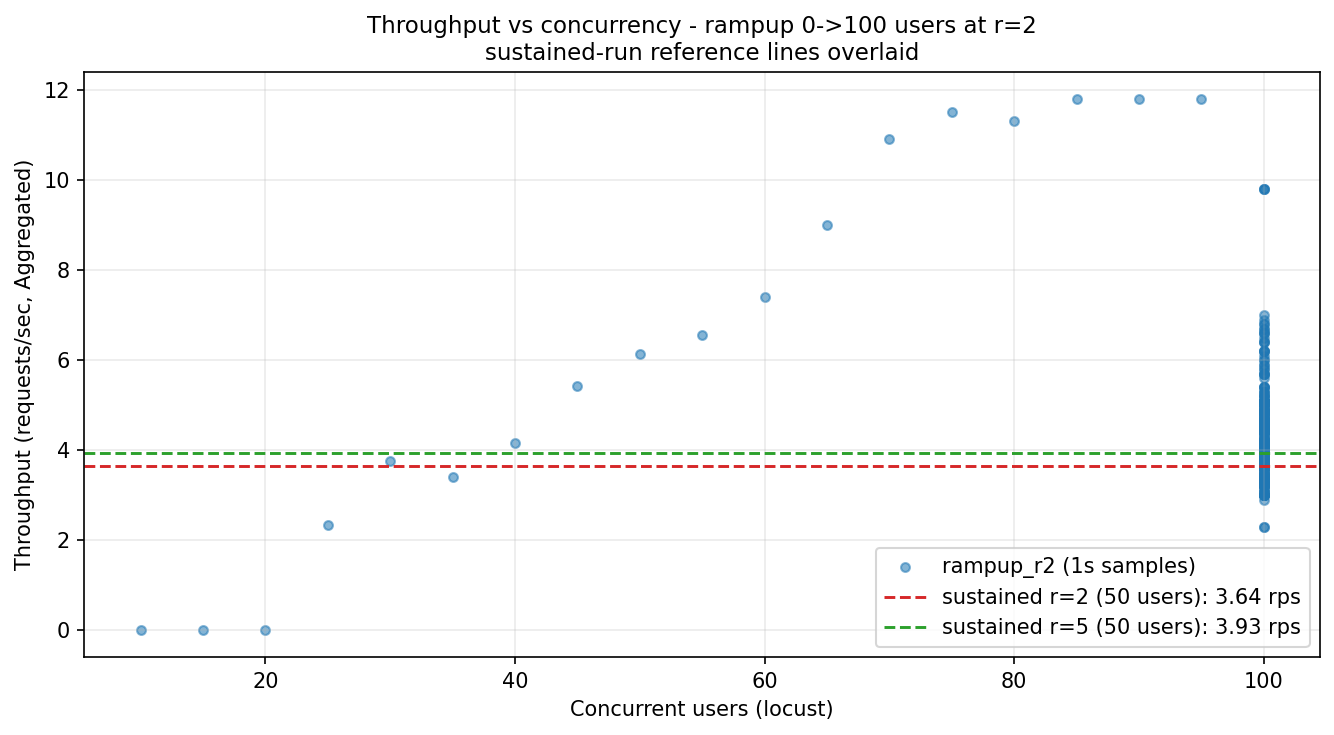

sustained r=2 rps: 3.64
sustained r=5 rps: 3.93
ratio (r=5 / r=2): 1.078x


In [4]:
# Chart 1: Throughput vs concurrent users (rampup_r2, per-second samples).
#
# Each dot is one second of the rampup run, plotted at (User Count, Requests/sec).
# Locust ramps users 0 -> 100 over ~5 minutes, so each user-count bucket gets only
# 1-2 samples. Treat the curve as a tracer for the *shape* of saturation, not a
# steady-state estimate. The two horizontal lines are the actual steady-state
# r=2 and r=5 sustained runs at 50 users (5 min each).

xs = [r["users"] for r in hist_rampup]
ys = [r["rps"] for r in hist_rampup]

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(xs, ys, s=18, alpha=0.55, color="#1f77b4", label="rampup_r2 (1s samples)")

sustained_r2_rps = scenarios["sustained_r2"]["aggregate"]["rps"]
sustained_r5_rps = scenarios["sustained_r5"]["aggregate"]["rps"]
ax.axhline(sustained_r2_rps, color="#d62728", linestyle="--", linewidth=1.4,
           label=f"sustained r=2 (50 users): {sustained_r2_rps:.2f} rps")
ax.axhline(sustained_r5_rps, color="#2ca02c", linestyle="--", linewidth=1.4,
           label=f"sustained r=5 (50 users): {sustained_r5_rps:.2f} rps")

ax.set_xlabel("Concurrent users (locust)")
ax.set_ylabel("Throughput (requests/sec, Aggregated)")
ax.set_title("Throughput vs concurrency - rampup 0->100 users at r=2\n"
             "sustained-run reference lines overlaid", fontsize=11)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(CHART_DIR / "01_throughput_vs_concurrency.png")
plt.show()
print(f"sustained r=2 rps: {sustained_r2_rps:.2f}")
print(f"sustained r=5 rps: {sustained_r5_rps:.2f}")
print(f"ratio (r=5 / r=2): {sustained_r5_rps / sustained_r2_rps:.3f}x")

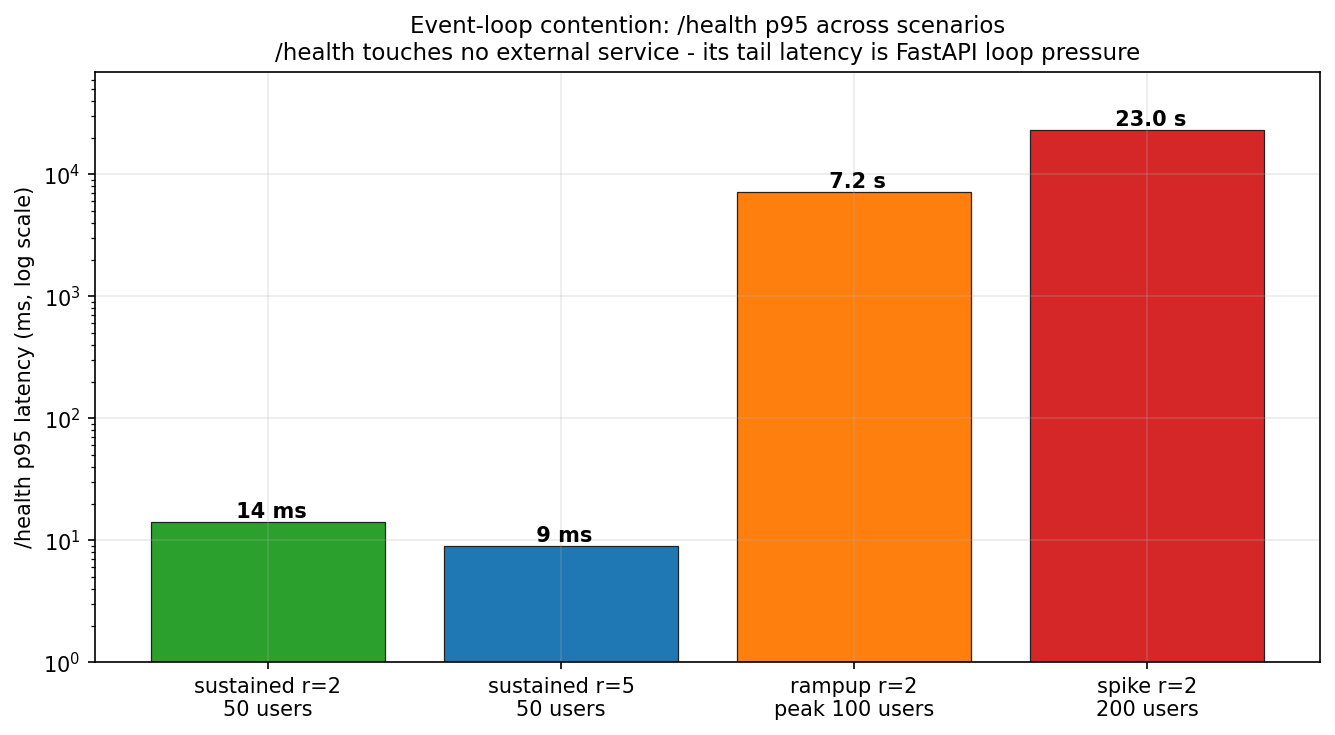

Per-scenario /health p95:
  sustained_r2   ->     14.0 ms
  sustained_r5   ->      9.0 ms
  rampup_r2      ->   7200.0 ms
  spike_r2       ->  23000.0 ms


In [5]:
# Chart 2: Event-loop contention - /health p95 across the four scenarios.
#
# /health has zero external dependencies (no LLM call, no embedding, no DB).
# Its p95 latency is therefore a clean thermometer for FastAPI event-loop
# pressure: anything above a few ms means the loop is blocked on something
# else (the synchronous BGE embedding inside async /query handlers).
#
# We pull the per-endpoint stats from each scenario's _stats.csv aggregate.

def health_p95(scenario: str) -> float:
    return float(scenarios[scenario]["by_endpoint"].get("/health", {}).get("p95_ms", 0.0))


labels = ["sustained r=2\n50 users", "sustained r=5\n50 users", "rampup r=2\npeak 100 users", "spike r=2\n200 users"]
keys = ["sustained_r2", "sustained_r5", "rampup_r2", "spike_r2"]
values = [health_p95(k) for k in keys]
colors = ["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, values, color=colors, edgecolor="#222", linewidth=0.6)

for b, v in zip(bars, values):
    label = f"{v:.0f} ms" if v < 1000 else f"{v/1000:.1f} s"
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f" {label}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("/health p95 latency (ms, log scale)")
ax.set_title("Event-loop contention: /health p95 across scenarios\n"
             "/health touches no external service - its tail latency is FastAPI loop pressure", fontsize=11)
ax.set_yscale("log")
ax.set_ylim(1, max(values) * 3)

plt.tight_layout()
plt.savefig(CHART_DIR / "02_event_loop_contention.png")
plt.show()
print("Per-scenario /health p95:")
for k, v in zip(keys, values):
    print(f"  {k:14s} -> {v:8.1f} ms")

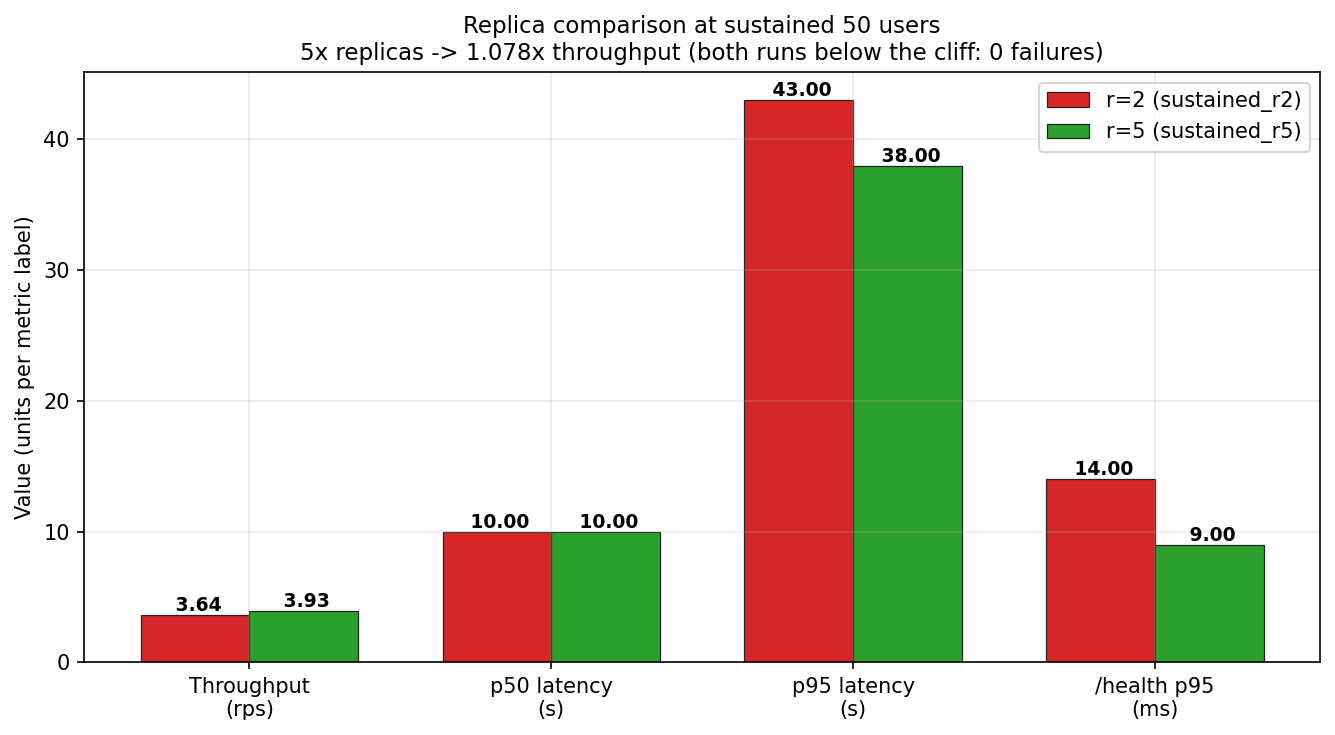

r=2 throughput: 3.64 rps
r=5 throughput: 3.93 rps
gain: 1.078x  (7.8% extra)


In [6]:
# Chart 3: Replica comparison - r=2 vs r=5 at fixed sustained load (50 users, 5 min).
#
# Both runs posted ZERO failures, so neither was capacity-bound. This measures
# scaling efficiency BELOW the saturation cliff, not whether r=5 raises the cliff.
# (See Chart 4 for the cliff itself.) The interpretation is in the JSON: at this
# load, cloud-LLM round-trip latency is the gating factor, so 2.5x more pods buys
# only modest extra headroom.

rc = data["replica_comparison"]
two = rc["two_replicas"]
five = rc["five_replicas"]

metrics = ["Throughput\n(rps)", "p50 latency\n(s)", "p95 latency\n(s)", "/health p95\n(ms)"]
two_vals = [two["throughput_rps"], two["p50_ms"] / 1000, two["p95_ms"] / 1000, health_p95("sustained_r2")]
five_vals = [five["throughput_rps"], five["p50_ms"] / 1000, five["p95_ms"] / 1000, health_p95("sustained_r5")]

x = np.arange(len(metrics))
w = 0.36

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, two_vals, w, label="r=2 (sustained_r2)", color="#d62728", edgecolor="#222", linewidth=0.6)
b2 = ax.bar(x + w/2, five_vals, w, label="r=5 (sustained_r5)", color="#2ca02c", edgecolor="#222", linewidth=0.6)

for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f" {b.get_height():.2f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Value (units per metric label)")
ax.set_title(f"Replica comparison at sustained 50 users\n"
             f"5x replicas -> {rc['throughput_gain_ratio']}x throughput "
             f"(both runs below the cliff: 0 failures)", fontsize=11)
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig(CHART_DIR / "03_replica_comparison.png")
plt.show()
print(f"r=2 throughput: {two['throughput_rps']:.2f} rps")
print(f"r=5 throughput: {five['throughput_rps']:.2f} rps")
print(f"gain: {rc['throughput_gain_ratio']:.3f}x  ({(rc['throughput_gain_ratio'] - 1) * 100:.1f}% extra)")

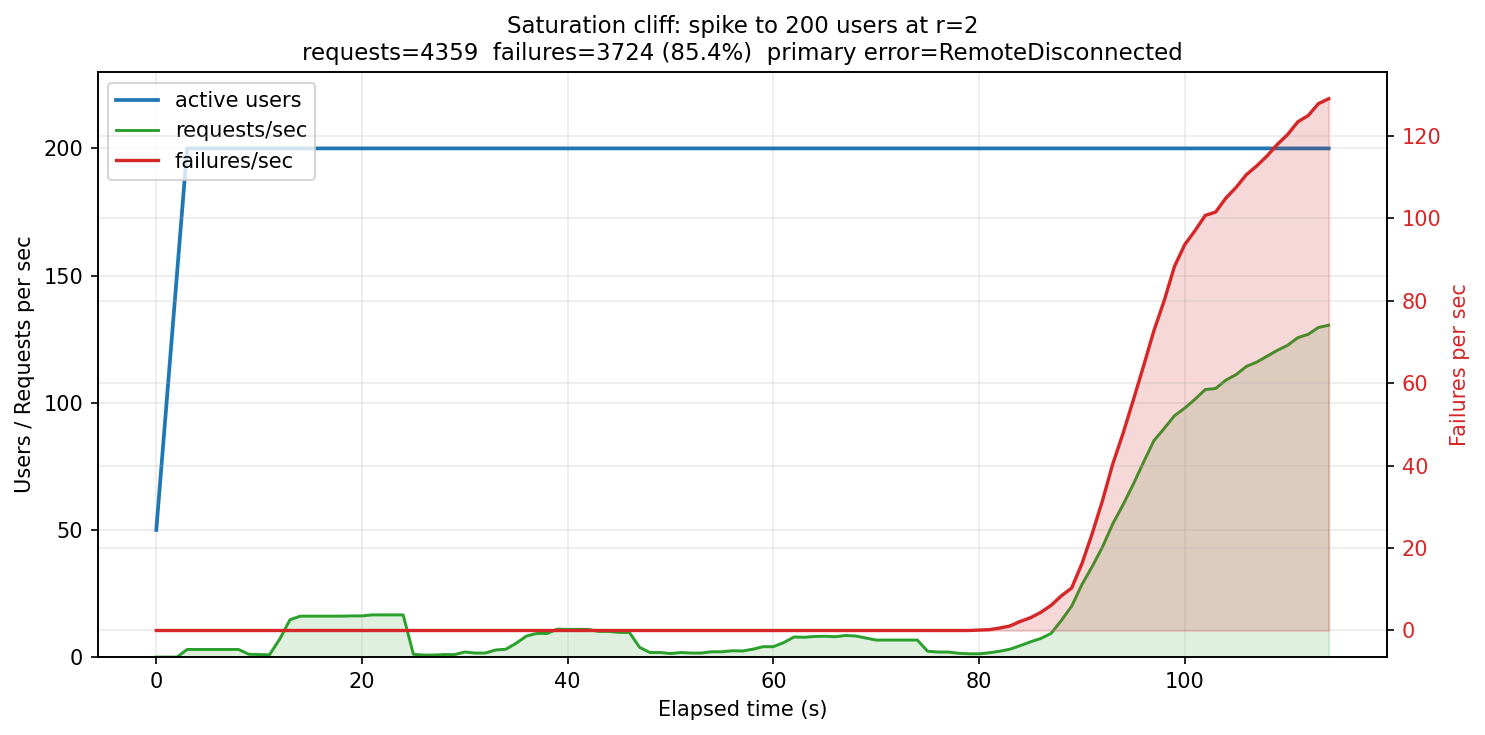

errors_by_type:
  RemoteDisconnected: 3633
  ConnectionResetError: 91

post-test observation: Both pods were SIGKILLed by the kubelet liveness probe at t~110s (5 consecutive failed /health probes inside the 75s window). The Deployment self-healed -- both pods restarted cleanly without operator intervention. p50=2ms is the connection-drop signature, not a real latency.


In [7]:
# Chart 4: Saturation cliff - spike scenario (200 users, r=2, 2 min) time series.
#
# Three signals on shared time axis:
#  - Active users (left axis)
#  - Requests/sec (left axis)
#  - Failures/sec (right axis, red)
#
# The cliff is visible as the moment failures/sec rises and stays elevated.
# Liveness probe SIGKILLs both pods around t~110s (visible in kubectl top logs:
# /tmp/k_top_phase3.log shows the 120s metrics-not-available gap). The cluster
# self-heals after load ends - no operator intervention required.

ts = [r["t_rel"] for r in hist_spike]
users = [r["users"] for r in hist_spike]
rps = [r["rps"] for r in hist_spike]
fps = [r["fps"] for r in hist_spike]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(ts, users, color="#1f77b4", linewidth=1.8, label="active users")
ax1.plot(ts, rps, color="#2ca02c", linewidth=1.4, label="requests/sec")
ax1.fill_between(ts, 0, rps, color="#2ca02c", alpha=0.15)
ax1.set_xlabel("Elapsed time (s)")
ax1.set_ylabel("Users / Requests per sec")
ax1.set_ylim(0, max(max(users), max(rps)) * 1.15)

ax2.plot(ts, fps, color="#d62728", linewidth=1.6, label="failures/sec")
ax2.fill_between(ts, 0, fps, color="#d62728", alpha=0.18)
ax2.set_ylabel("Failures per sec", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

sc = data["saturation_cliff"]
ax1.set_title(
    f"Saturation cliff: spike to 200 users at r=2\n"
    f"requests={sc['requests']}  failures={sc['failures']} ({sc['failure_rate'] * 100:.1f}%)  "
    f"primary error={sc['primary_error']}",
    fontsize=11,
)

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc="upper left")

plt.tight_layout()
plt.savefig(CHART_DIR / "04_saturation_cliff.png")
plt.show()
print("errors_by_type:")
for k, v in sc["errors_by_type"].items():
    print(f"  {k}: {v}")
print(f"\npost-test observation: {sc['post_test_observation']}")

## Findings

**1. Replicas alone do not buy throughput.** At sustained 50 users, scaling from r=2 to r=5 (2.5x more pods) lifted RPS from 3.64 to 3.93 - a 1.08x gain. Both runs posted zero failures, so neither was capacity-bound; the gating factor at this load is cloud-LLM round-trip latency (Groq llama-3.1-8b-instant), and adding pods does not relieve an LLM-egress-bound queue. Whether r=5 raises the *cliff itself* (the 200-user spike that broke r=2) is unmeasured here - documented as future work in the JSON.

**2. The event loop is the visible bottleneck, not pod CPU.** `/health` does no LLM call, no embedding, no DB hit; its tail latency is therefore a clean thermometer for FastAPI loop pressure. At sustained 50 users (r=2) `/health` p95 is 14ms; at peak 100 users (r=2) the same endpoint reports a 7.2-second p95. The cause is the synchronous BGE-base-en-v1.5 embedding step running inside an `async def` handler: while one request is mid-embed, the loop is blocked for every other request on that worker, including `/health`. CPU per pod was 25-30% at sustained load and only 79% at the spike peak - the pods had spare cores; they just did not have spare event loops.

**3. The 2-replica setup has a real saturation cliff.** The 200-user spike posted 85.4% failures (3,633 RemoteDisconnected, 91 ConnectionResetError). Pods saturated, the liveness probe SIGKILLed both around t~110s (visible as the 120s metrics gap in `/tmp/k_top_phase3.log`), and the cluster self-healed after load ended - no operator intervention. The failure signature is informative: `RemoteDisconnected` says "the pod accepted the connection then hung up mid-response," which is exactly what you expect when a worker is killed mid-flight. This is the qualitative difference between a saturated-but-recovering system and the Phase 1 v0 "99% failure" pattern that turned out to be a port-forward death (see git history for that diagnosis).

**4. The 1-second default liveness timeout is wrong for this workload.** Phase 1 v0 SIGKILLed a working pod under embedding-saturated CPU because the default `httpGet` timeoutSeconds is 1s, and `/health` (despite zero dependencies) cannot answer within that budget when the event loop is blocked. We tuned to `timeoutSeconds: 5, periodSeconds: 15, failureThreshold: 5` (75-second kill window): wide enough to absorb realistic LLM-bound bursts, narrow enough to still kill genuinely stalled pods. The retake confirmed the new bounds: pods survived the rampup and only died when the spike actually saturated them.

**5. Apparent memory creep is load-proportional, not a leak.** At Phase 2 (25 users/pod, r=2) one pod accumulated +204Mi over 5 minutes - looked like a leak. Phase 5 (10 users/pod, r=5) showed only +27Mi average across all 5 pods over the same window. Working-set growth scales with concurrent-request count, not wall time, so the diagnosis is loaded working-set inflation (BGE embedding caches, FastAPI request buffers), not an unbounded leak.

**Methodology caveats.** Single-node Docker Desktop K8s on Apple M4 Pro 16GB; HPA disabled per D5 to isolate replica count as a single variable; embedding runs on CPU because Linux containers cannot use the host MPS backend. The point of these runs is to expose the bottlenecks of the stack itself, not to publish production capacity numbers. See `methodology` block in the JSON for the full configuration.